# Text preprocesing with 13 channels

In [1]:
import os
os.environ['KAGGLE_TOKEN'] = 'KGAT_cab06bf05db26ba44aa3baba6b6d3cfc'
print("Token set!")

Token set!


In [2]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token
print("Configured!")

Configured!


In [3]:
!pip install kaggle -q
print("Kaggle installed!")

Kaggle installed!


In [4]:
!kaggle datasets list -s "onera satellite change detection"

ref                                                     title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
soumikrakshit/onera-satellite-change-detection-dataset  Onera Satellite Change Detection Dataset   528886531  2019-07-20 21:22:19.673000           2572         10  0.6875           
moinakboss/onera-dataset                                Onera Satellite Change Detection Dataset   528974458  2021-03-29 12:53:44.830000             64          1  0.1875           
saverino/oscd-msi                                       OSCD_MSI                                   528730050  2025-06-21 12:55:09.257000             74          0  0.875            


In [5]:
!kaggle datasets download -d soumikrakshit/onera-satellite-change-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/soumikrakshit/onera-satellite-change-detection-dataset
License(s): unknown
100% 504M/504M [00:03<00:00, 151MB/s] 



In [6]:
!unzip onera-satellite-change-detection-dataset.zip -d /content/OSCD/
print("Unzipped!")

Archive:  onera-satellite-change-detection-dataset.zip
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/README.txt  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/abudhabi.geojson  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/dates.txt  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/imgs_1/S2A_OPER_MSI_L1C_TL_MTI__20160120T104345_A003020_T39QZG_B01.tif  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/imgs_1/S2A_OPER_MSI_L1C_TL_MTI__20160120T104345_A003020_T39QZG_B02.tif  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/imgs_1/S2A_OPER_MSI_L1C_TL_MTI__20160120T104345_A003020_T39QZG_B03.tif  
  inflating: /content/OSCD/images/Onera Satellite Change Detection dataset - Images/abudhabi/imgs_1/S2A_OPER_MSI_L1C_TL_MTI__20160120

### 1. Imports


In [7]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt



### 2. Paths + Config

In [8]:
# Paths & Constants
base_path   = "/content/OSCD/images/Onera Satellite Change Detection dataset - Images/"
labels_path = "/content/OSCD/train_labels/Onera Satellite Change Detection dataset - Train Labels/"

SELECTED_CITIES = ['mumbai', 'abudhabi']

BANDS = ['B01.tif','B02.tif','B03.tif','B04.tif','B05.tif','B06.tif',
         'B07.tif','B08.tif','B09.tif','B10.tif','B11.tif','B12.tif','B8A.tif']

CROPS = {
    'mumbai':   (0,   0, 430, 557),
    'abudhabi': (400, 0, 799, 785)
}

TILE_SIZE = 64
STRIDE    = 32


###  3. Reading multi-channel satellite images and label loading

In [9]:
def load_13bands(city_path, folder, crop):
    r1, c1, r2, c2 = crop
    bands = []
    for band in BANDS:
        with rasterio.open(os.path.join(city_path, folder, band)) as src:
            b = src.read(1).astype(np.float32)
            b = b[r1:r2, c1:c2]
            bands.append(b)
    return np.stack(bands, axis=-1)

def load_label(city, crop):
    r1, c1, r2, c2 = crop
    with rasterio.open(os.path.join(labels_path, city, "cm", f"{city}-cm.tif")) as src:
        label = src.read(1).astype(np.float32)
        label = label[r1:r2, c1:c2]
    return (label - 1).astype(np.uint8)

def normalize_bands(img):
    normalized = np.zeros_like(img)
    for i in range(img.shape[-1]):
        band = img[:,:,i]
        bmin = np.nanmin(band)
        bmax = np.nanmax(band)
        if bmax - bmin > 0:
            normalized[:,:,i] = (band - bmin) / (bmax - bmin)
    return normalized


### 4. Visualizing multi-channel data

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


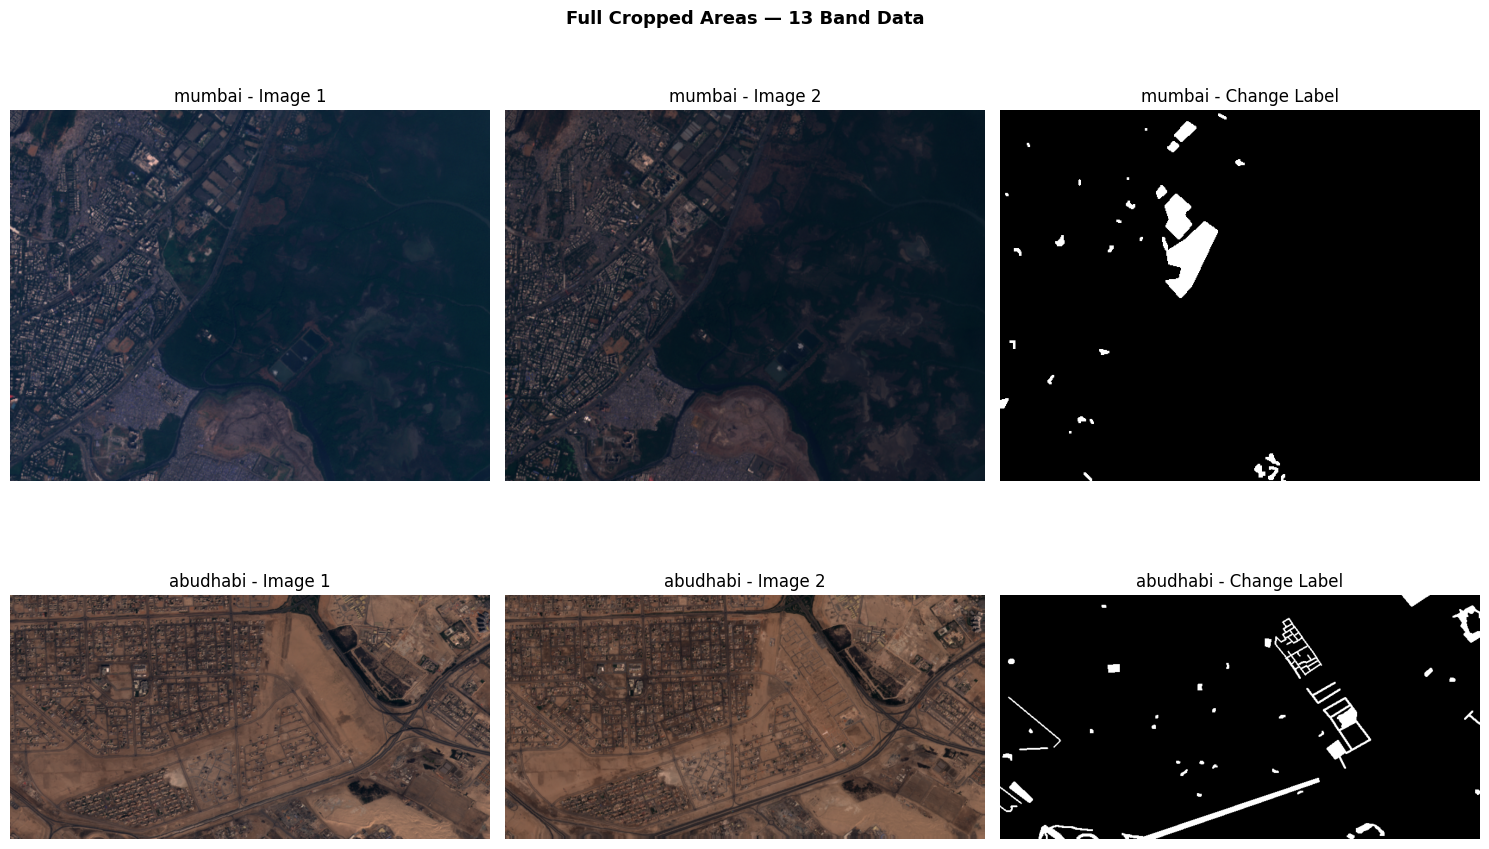

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, city in enumerate(SELECTED_CITIES):
    city_path = os.path.join(base_path, city)
    crop = CROPS[city]

    img1  = load_13bands(city_path, "imgs_1_rect", crop)
    img2  = load_13bands(city_path, "imgs_2_rect", crop)
    label = load_label(city, crop)

    rgb1 = img1[:, :, [3, 2, 1]]
    rgb2 = img2[:, :, [3, 2, 1]]
    rgb1 = (rgb1 - rgb1.min()) / (rgb1.max() - rgb1.min())
    rgb2 = (rgb2 - rgb2.min()) / (rgb2.max() - rgb2.min())

    axes[i][0].imshow(rgb1)
    axes[i][0].set_title(f"{city} - Image 1")
    axes[i][0].axis('off')

    axes[i][1].imshow(rgb2)
    axes[i][1].set_title(f"{city} - Image 2")
    axes[i][1].axis('off')

    axes[i][2].imshow(label, cmap='gray')
    axes[i][2].set_title(f"{city} - Change Label")
    axes[i][2].axis('off')

plt.suptitle("Full Cropped Areas — 13 Band Data", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Channel stacking / preprocessing

In [11]:
all_patches = {'img1': [], 'img2': [], 'label': []}

for city in SELECTED_CITIES:
    city_path = os.path.join(base_path, city)
    crop = CROPS[city]

    img1  = load_13bands(city_path, "imgs_1_rect", crop)
    img2  = load_13bands(city_path, "imgs_2_rect", crop)
    label = load_label(city, crop)

    img1  = normalize_bands(img1)
    img2  = normalize_bands(img2)

    H, W = img1.shape[:2]
    city_count = 0

    for row in range(0, H - TILE_SIZE + 1, STRIDE):
        for col in range(0, W - TILE_SIZE + 1, STRIDE):
            all_patches['img1'].append(img1[row:row+TILE_SIZE, col:col+TILE_SIZE])
            all_patches['img2'].append(img2[row:row+TILE_SIZE, col:col+TILE_SIZE])
            all_patches['label'].append(label[row:row+TILE_SIZE, col:col+TILE_SIZE])
            city_count += 1

    print(f"{city}: {city_count} patches")

print(f"\nTotal patches: {len(all_patches['img1'])}")
print(f"Patch shape: {all_patches['img1'][0].shape}")

mumbai: 192 patches
abudhabi: 253 patches

Total patches: 445
Patch shape: (64, 64, 13)


### 6. Visualize 13 Band Patches

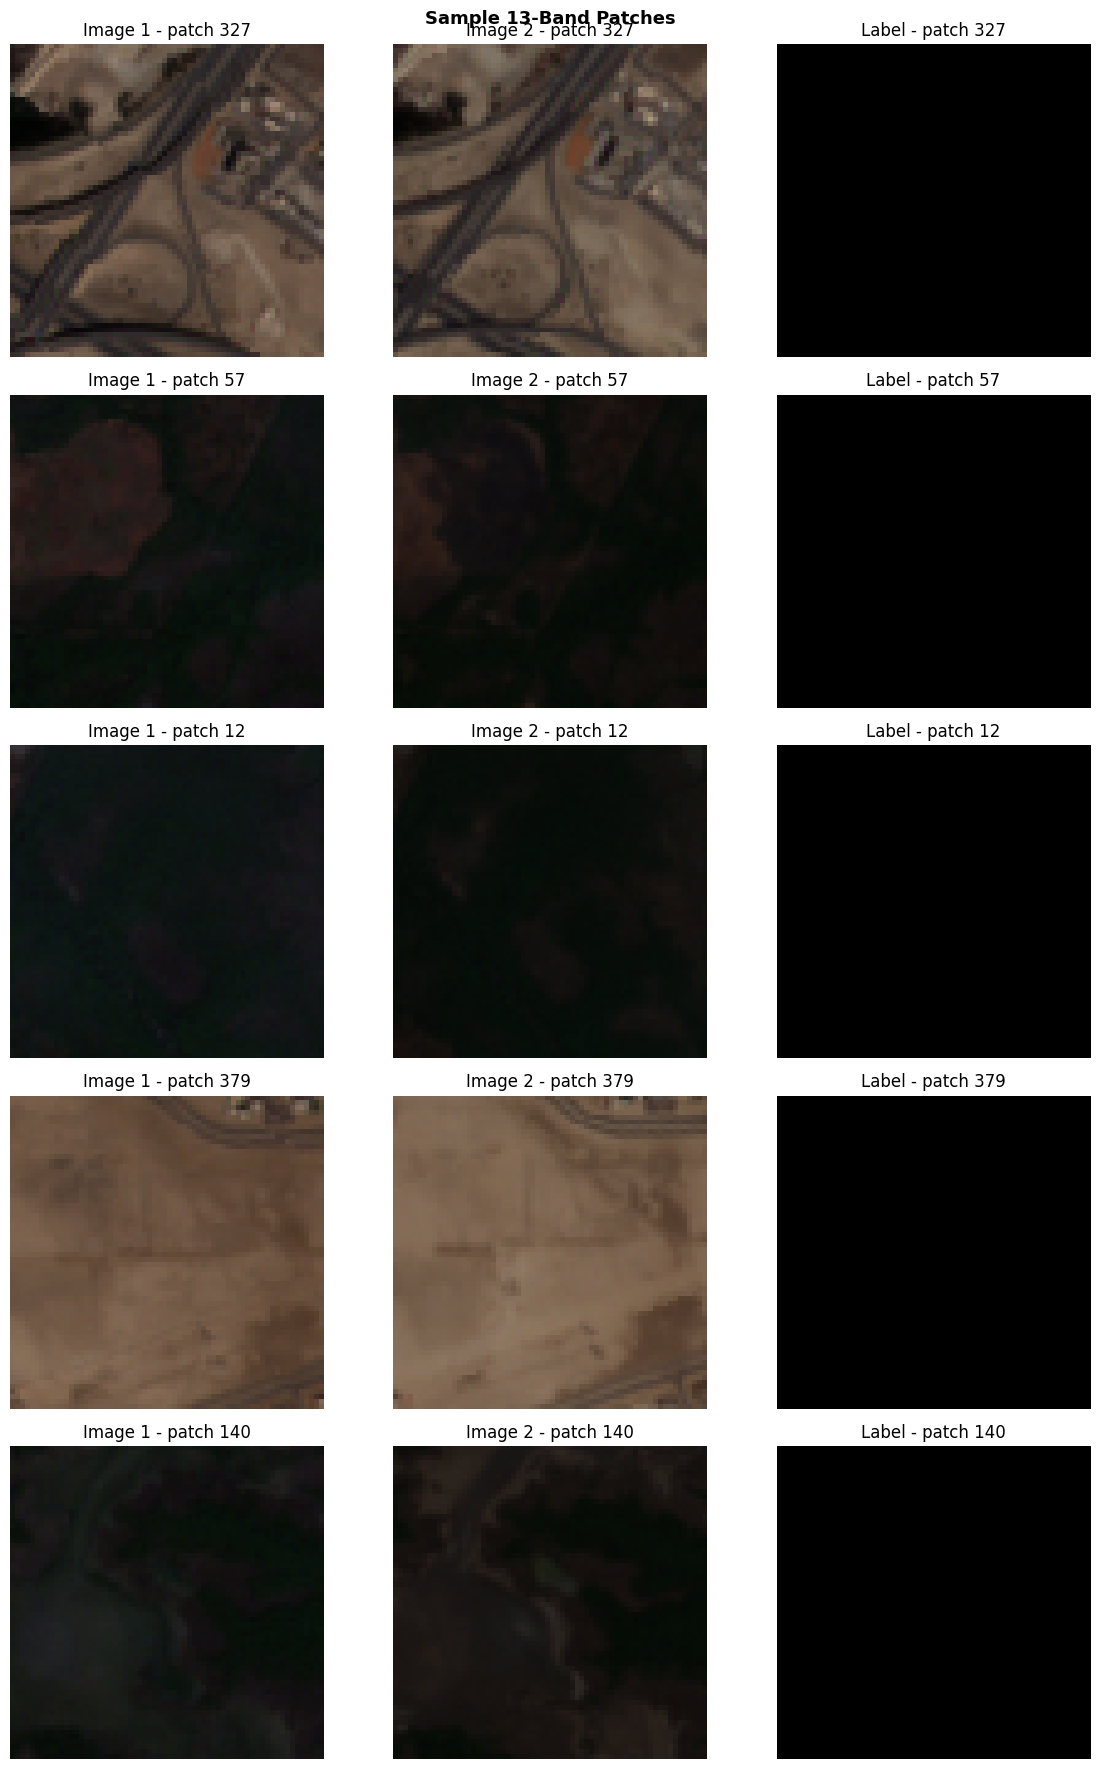

In [13]:
import random
random.seed(42)
sample_idx = random.sample(range(len(all_patches['img1'])), 5)

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i, idx in enumerate(sample_idx):
    rgb1 = all_patches['img1'][idx][:, :, [3, 2, 1]]
    rgb2 = all_patches['img2'][idx][:, :, [3, 2, 1]]
    lbl  = all_patches['label'][idx]

    axes[i][0].imshow(rgb1)
    axes[i][0].set_title(f"Image 1 - patch {idx}")
    axes[i][0].axis('off')

    axes[i][1].imshow(rgb2)
    axes[i][1].set_title(f"Image 2 - patch {idx}")
    axes[i][1].axis('off')

    axes[i][2].imshow(lbl, cmap='gray')
    axes[i][2].set_title(f"Label - patch {idx}")
    axes[i][2].axis('off')

plt.suptitle("Sample 13-Band Patches", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. Dataset statistics / sanity checks



In [14]:
patches_with_changes    = sum(1 for l in all_patches['label'] if l.sum() > 0)
patches_without_changes = len(all_patches['label']) - patches_with_changes

print(f"Patches WITH changes:    {patches_with_changes}")
print(f"Patches WITHOUT changes: {patches_without_changes}")
print(f"Change ratio: {patches_with_changes/len(all_patches['label'])*100:.1f}%")

Patches WITH changes:    216
Patches WITHOUT changes: 229
Change ratio: 48.5%


### 7. Check average brightness of each patch

In [15]:
brightness = [all_patches['img1'][i][:,:,[3,2,1]].mean() for i in range(len(all_patches['img1']))]
print(f"Min brightness:  {min(brightness):.4f}")
print(f"Max brightness:  {max(brightness):.4f}")
print(f"Mean brightness: {sum(brightness)/len(brightness):.4f}")

Min brightness:  0.0442
Max brightness:  0.4257
Mean brightness: 0.2188


###8.  Filter Dark Patches

In [16]:
BRIGHTNESS_THRESHOLD = 0.10

filtered = {'img1': [], 'img2': [], 'label': []}

for i in range(len(all_patches['img1'])):
    b = all_patches['img1'][i][:,:,[3,2,1]].mean()
    if b >= BRIGHTNESS_THRESHOLD:
        filtered['img1'].append(all_patches['img1'][i])
        filtered['img2'].append(all_patches['img2'][i])
        filtered['label'].append(all_patches['label'][i])

patches_with_changes    = sum(1 for l in filtered['label'] if l.sum() > 0)
patches_without_changes = len(filtered['label']) - patches_with_changes

print(f"Total patches after filtering: {len(filtered['img1'])}")
print(f"Patches WITH changes:    {patches_with_changes}")
print(f"Patches WITHOUT changes: {patches_without_changes}")
print(f"Change ratio: {patches_with_changes/len(filtered['label'])*100:.1f}%")

Total patches after filtering: 351
Patches WITH changes:    211
Patches WITHOUT changes: 140
Change ratio: 60.1%


### 9. Visualize Filtered Patches

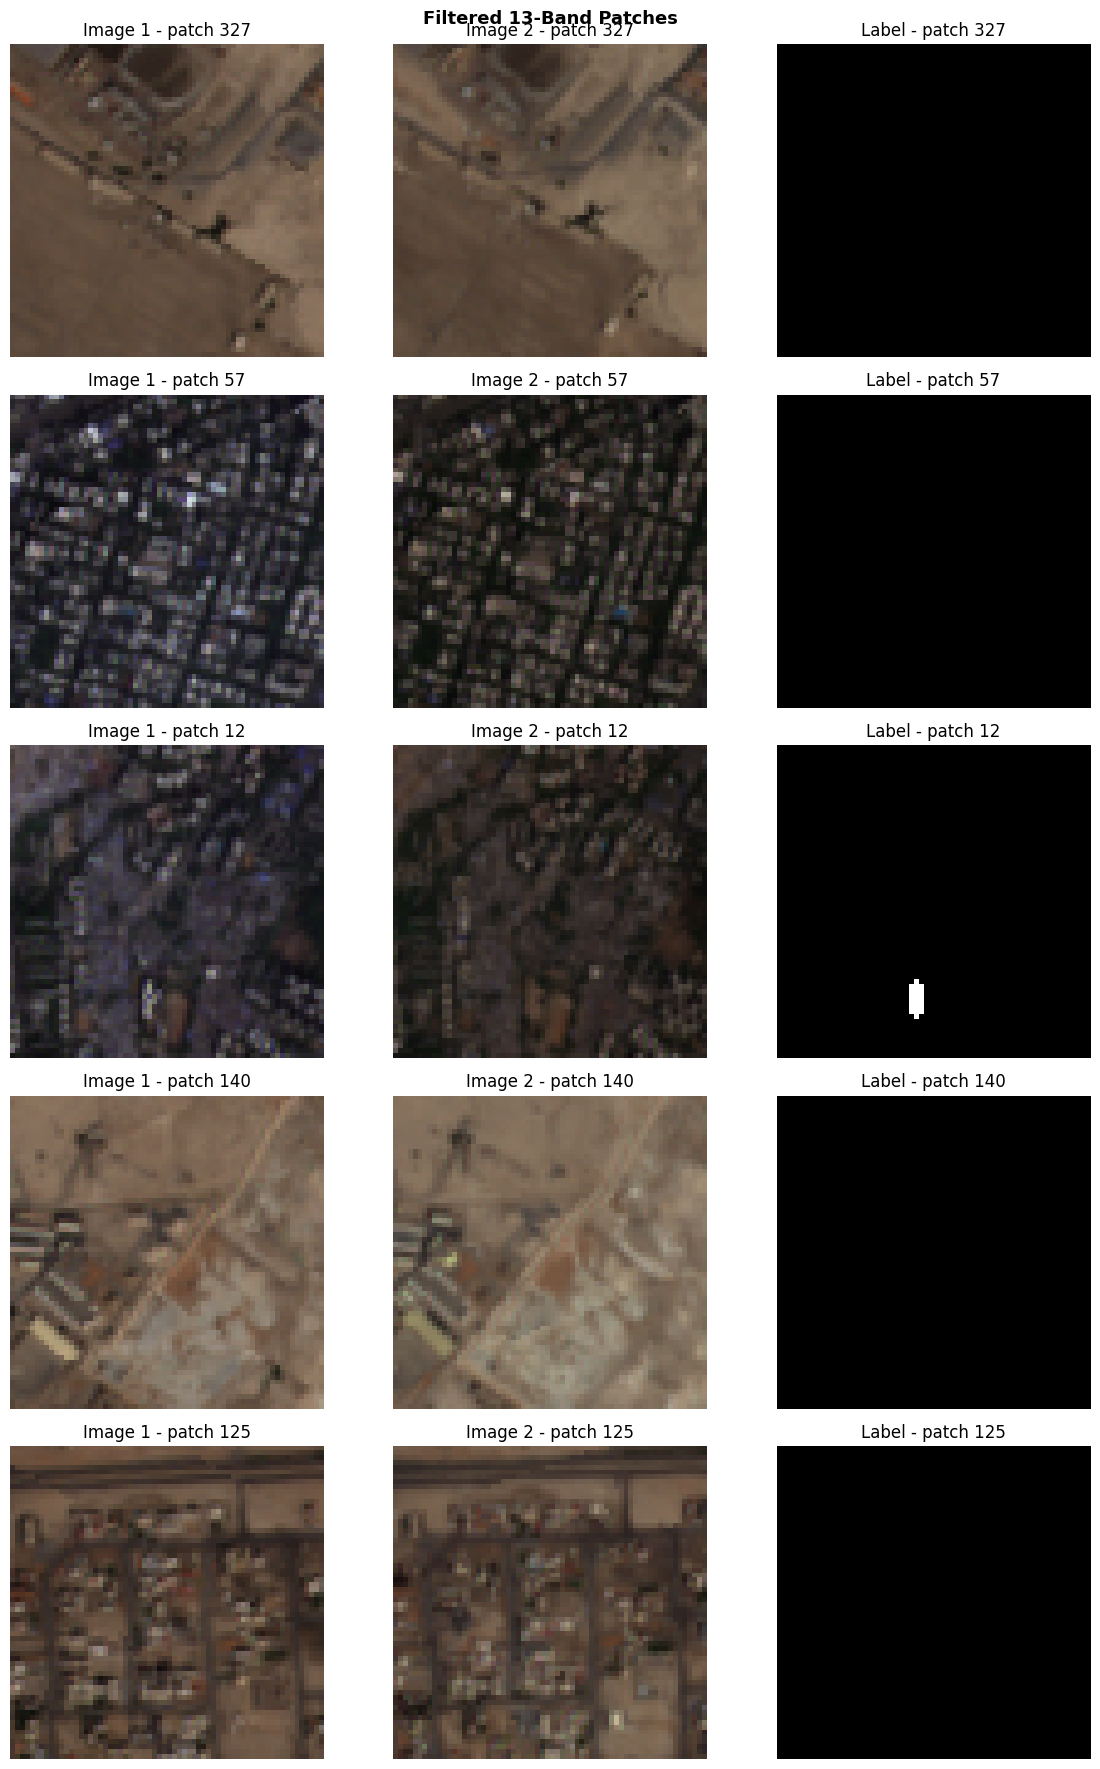

In [17]:
import random
random.seed(42)
sample_idx = random.sample(range(len(filtered['img1'])), 5)

fig, axes = plt.subplots(5, 3, figsize=(12, 18))

for i, idx in enumerate(sample_idx):
    rgb1 = filtered['img1'][idx][:, :, [3, 2, 1]]
    rgb2 = filtered['img2'][idx][:, :, [3, 2, 1]]
    lbl  = filtered['label'][idx]

    axes[i][0].imshow(rgb1)
    axes[i][0].set_title(f"Image 1 - patch {idx}")
    axes[i][0].axis('off')

    axes[i][1].imshow(rgb2)
    axes[i][1].set_title(f"Image 2 - patch {idx}")
    axes[i][1].axis('off')

    axes[i][2].imshow(lbl, cmap='gray')
    axes[i][2].set_title(f"Label - patch {idx}")
    axes[i][2].axis('off')

plt.suptitle("Filtered 13-Band Patches", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 10. crop a smaller urban area and Split & Save

In [19]:
img1_arr  = np.array(filtered['img1'])
img2_arr  = np.array(filtered['img2'])
label_arr = np.array(filtered['label'])

print(f"img1 shape:  {img1_arr.shape}")
print(f"img2 shape:  {img2_arr.shape}")
print(f"label shape: {label_arr.shape}")

# Shuffle
np.random.seed(42)
indices   = np.random.permutation(len(img1_arr))

train_end = int(0.70 * len(indices))
val_end   = int(0.85 * len(indices))

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

# Save
os.makedirs("/content/splits_13band/", exist_ok=True)

np.savez_compressed("/content/splits_13band/train.npz",
    img1=img1_arr[train_idx], img2=img2_arr[train_idx], labels=label_arr[train_idx])

np.savez_compressed("/content/splits_13band/val.npz",
    img1=img1_arr[val_idx], img2=img2_arr[val_idx], labels=label_arr[val_idx])

np.savez_compressed("/content/splits_13band/test.npz",
    img1=img1_arr[test_idx], img2=img2_arr[test_idx], labels=label_arr[test_idx])

print(f"\nTrain: {len(train_idx)}")
print(f"Val:   {len(val_idx)}")
print(f"Test:  {len(test_idx)}")


img1 shape:  (351, 64, 64, 13)
img2 shape:  (351, 64, 64, 13)
label shape: (351, 64, 64)

Train: 245
Val:   53
Test:  53


### 11. save / zip / export

In [20]:
import shutil
from google.colab import files

shutil.make_archive("/content/oscd_13band_mumbai_abudhabi", 'zip', "/content/splits_13band/")
print("ZIP created!")

files.download("/content/oscd_13band_mumbai_abudhabi.zip")

ZIP created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>